# Packages

In [1]:
import numpy as np
import pandas as pd
import os 

import warnings
warnings.filterwarnings('ignore')

# Choose directory
directory = "C:/Users/Fede/OneDrive/Projects/prorindes"
os.chdir(directory)

files_datain = "data/raw_data/"
files_dataout = "data/processed_data/"
files_plots = "plots/"


In [2]:
files_plots = files_plots + "enso/"

In [3]:

# scripts with all plot packages and functions
import scripts.functions_plots as fp
from scripts.functions_plots import *
# create_base_map, facet_plot, map_plot, pyplot package and others

# Files

In [4]:
df_enso = pd.read_csv(files_datain + "ENSO_34_oni.csv")

df_yield = pd.read_csv(files_dataout + "yield_averaged_across_management_soil.csv")

df_precip = pd.read_csv(files_dataout + "precipitation_new.csv")

df_locations = pd.read_csv(files_dataout + "location_info.csv")

In [5]:
# reorder categories!!
order = ["Reconquista","Paraná","Gualeguaychú","Río Cuarto","Marcos Juárez",
         "Laboulaye","Junín","Pehuajó","Nueve de Julio","Coronel Suárez","Tandil","Tres Arroyos"]

df_yield['location'] = df_yield["location"].astype("category").cat.reorder_categories(order)
df_precip['location'] = df_precip["location"].astype("category").cat.reorder_categories(order)
df_locations['location'] = df_locations["location"].astype("category").cat.reorder_categories(order)


# ENSO. filter columns, create labels

In [6]:
# choose range of months
#df_enso = df_enso.drop(columns=["MJJ","NDJ","DJF","JFM","FMA","MAM","AMJ"]).copy()
selected_columns = ["JJA","JAS","ASO","SON"]
df_enso = df_enso[["Year"]+selected_columns].copy()
# Create new index based on the average 
df_enso["enso_mean"] = df_enso[selected_columns].mean (axis = 1)
# label depending on value
df_enso["phase"] = pd.cut(
        df_enso["enso_mean"],
        bins=[-np.inf, -0.4, 0.4, np.inf],
        labels=["LN", "N", "EN"]
    )

phase = "phase"

### Plot labels

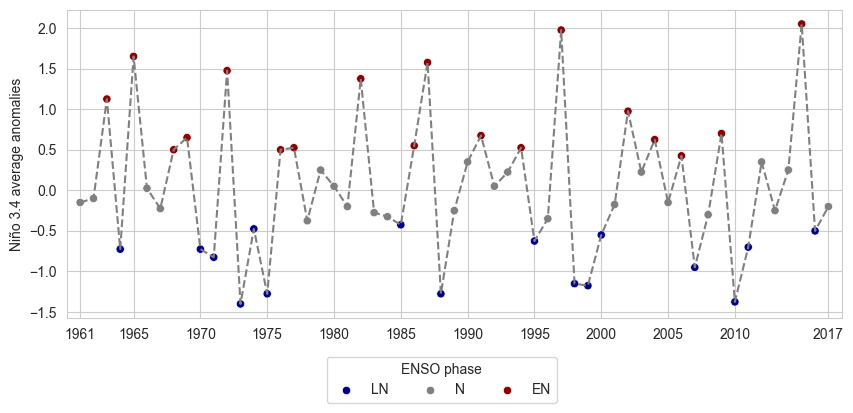

In [8]:
sns.set_style("whitegrid")
    
fig, ax = plt.subplots(figsize=(10, 4))

sns.lineplot(
    data=df_enso,
    x="Year",
    y="enso_mean",
    ax=ax, color = "grey", linestyle = "dashed"
)

gscatter = sns.scatterplot(
    data=df_enso,
    x="Year",
    y= "enso_mean",
    hue= phase,
    palette={
        "LN": "darkblue",
        "N": "grey",
        "EN": "darkred"
    },
    ax=ax
)

ax.set_ylabel("Niño 3.4 average anomalies") 
ax.set_xlim(1960, 2018)
ax.set_xticks([1961, 1965, 1970, 1975, 1980, 1985, 1990, 1995, 2000, 2005, 2010, 2017])
ax.set_xlabel(None)
# Legend below the plot
handles, labels = gscatter.get_legend_handles_labels()

ax.legend_.remove()
fig.legend(
    handles,
    labels,
    title="ENSO phase",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3
)

plt.savefig(files_plots +   "ENSO_index_series"+phase+".png",dpi=300,bbox_inches='tight')

# YIeld and ENSO

In [9]:
df_merge = df_yield.copy().merge(df_enso.rename(columns={"Year":"year"}),
                                 on = "year")
df_merge["yield_kg_ha"]= df_merge["yield_kg_ha"].astype(float)

# Yield climatology with ENSO

In [10]:
def plot_boxplots(df, without_neutral=False, subgroup=None,
                  
                  col_wrap=None, filename="plot.png"):

    dftoplot = df.copy()

    # Remove neutral phase if requested
    if without_neutral:
        dftoplot = dftoplot[dftoplot[phase] != "N"].copy()
        dftoplot[phase] = dftoplot[phase].cat.remove_categories("N")
        palette = {"EN": "darkred", "LN": "darkblue"}
    else:
        palette = {"EN": "darkred", "N": "darkgreen", "LN": "darkblue"}

    # Select subgroup if requested
    if subgroup is not None:
        dftoplot = dftoplot[dftoplot["location"].isin(subgroup)].copy()
        dftoplot["location"] = (
            dftoplot["location"]
            .cat.remove_unused_categories()
        )

    g = fp.facet_plot(
        data=dftoplot,
        plot_func=sns.boxplot,
        col="location",
        col_wrap=col_wrap,
        x="initial_sw",
        y="yield_kg_ha",
        hue=phase,
        fill=False,
        legend_title="ENSO",
        palette=palette,
    )

    g.set(
        xlabel="Initial S.W",
        ylabel="Yield [kg/ha]"
    )

    g.map_dataframe(
        sns.stripplot,
        x="initial_sw",
        y="yield_kg_ha",
        dodge=True,
        hue=phase,
        palette=palette,
    )

    plt.savefig(
        files_plots + filename,
        dpi=300,
        bbox_inches="tight"
    )
    plt.close()

In [11]:
subgroup = ["Paraná", "Marcos Juárez", "Pehuajó", "Tandil"]

configs = [
    dict(
        without_neutral=True,
        subgroup=None,
        col_wrap=3,
        filename="ENSO_noneutral_yield_boxplots.png",
    ),
    dict(
        without_neutral=False,
        subgroup=None,
        col_wrap=3,
        filename="ENSO_yield_boxplots.png",
    ),
    dict(
        without_neutral=True,
        subgroup=subgroup,
        col_wrap=2,
        filename="ENSO_noneutral_yield_boxplots_subgroups.png",
    ),
    dict(
        without_neutral=False,
        subgroup=subgroup,
        col_wrap=2,
        filename="ENSO_yield_boxplots_subgroups.png",
    ),
]

for cfg in configs:
    plot_boxplots(df_merge, **cfg)

### Map

In [12]:
df_merge_average= ( df_merge[df_merge[phase]!= "N"].groupby(
    ["location","initial_sw","latitude","longitude",phase])["yield_kg_ha"].
    mean().reset_index().dropna()   )

In [13]:
df_merge_average_pivot = df_merge_average.pivot(index = ["location","latitude","longitude"],
                                                 columns=["initial_sw",phase],
                                                 values = "yield_kg_ha").reset_index()

In [14]:
df_merge_average_pivot["High"]["Difference"] = (
    df_merge_average_pivot["High"]["EN"] - 
    df_merge_average_pivot["High"]["LN"]
)

df_merge_average_pivot["Low"]["Difference"] = (
    df_merge_average_pivot["Low"]["EN"] - 
    df_merge_average_pivot["Low"]["LN"]
)

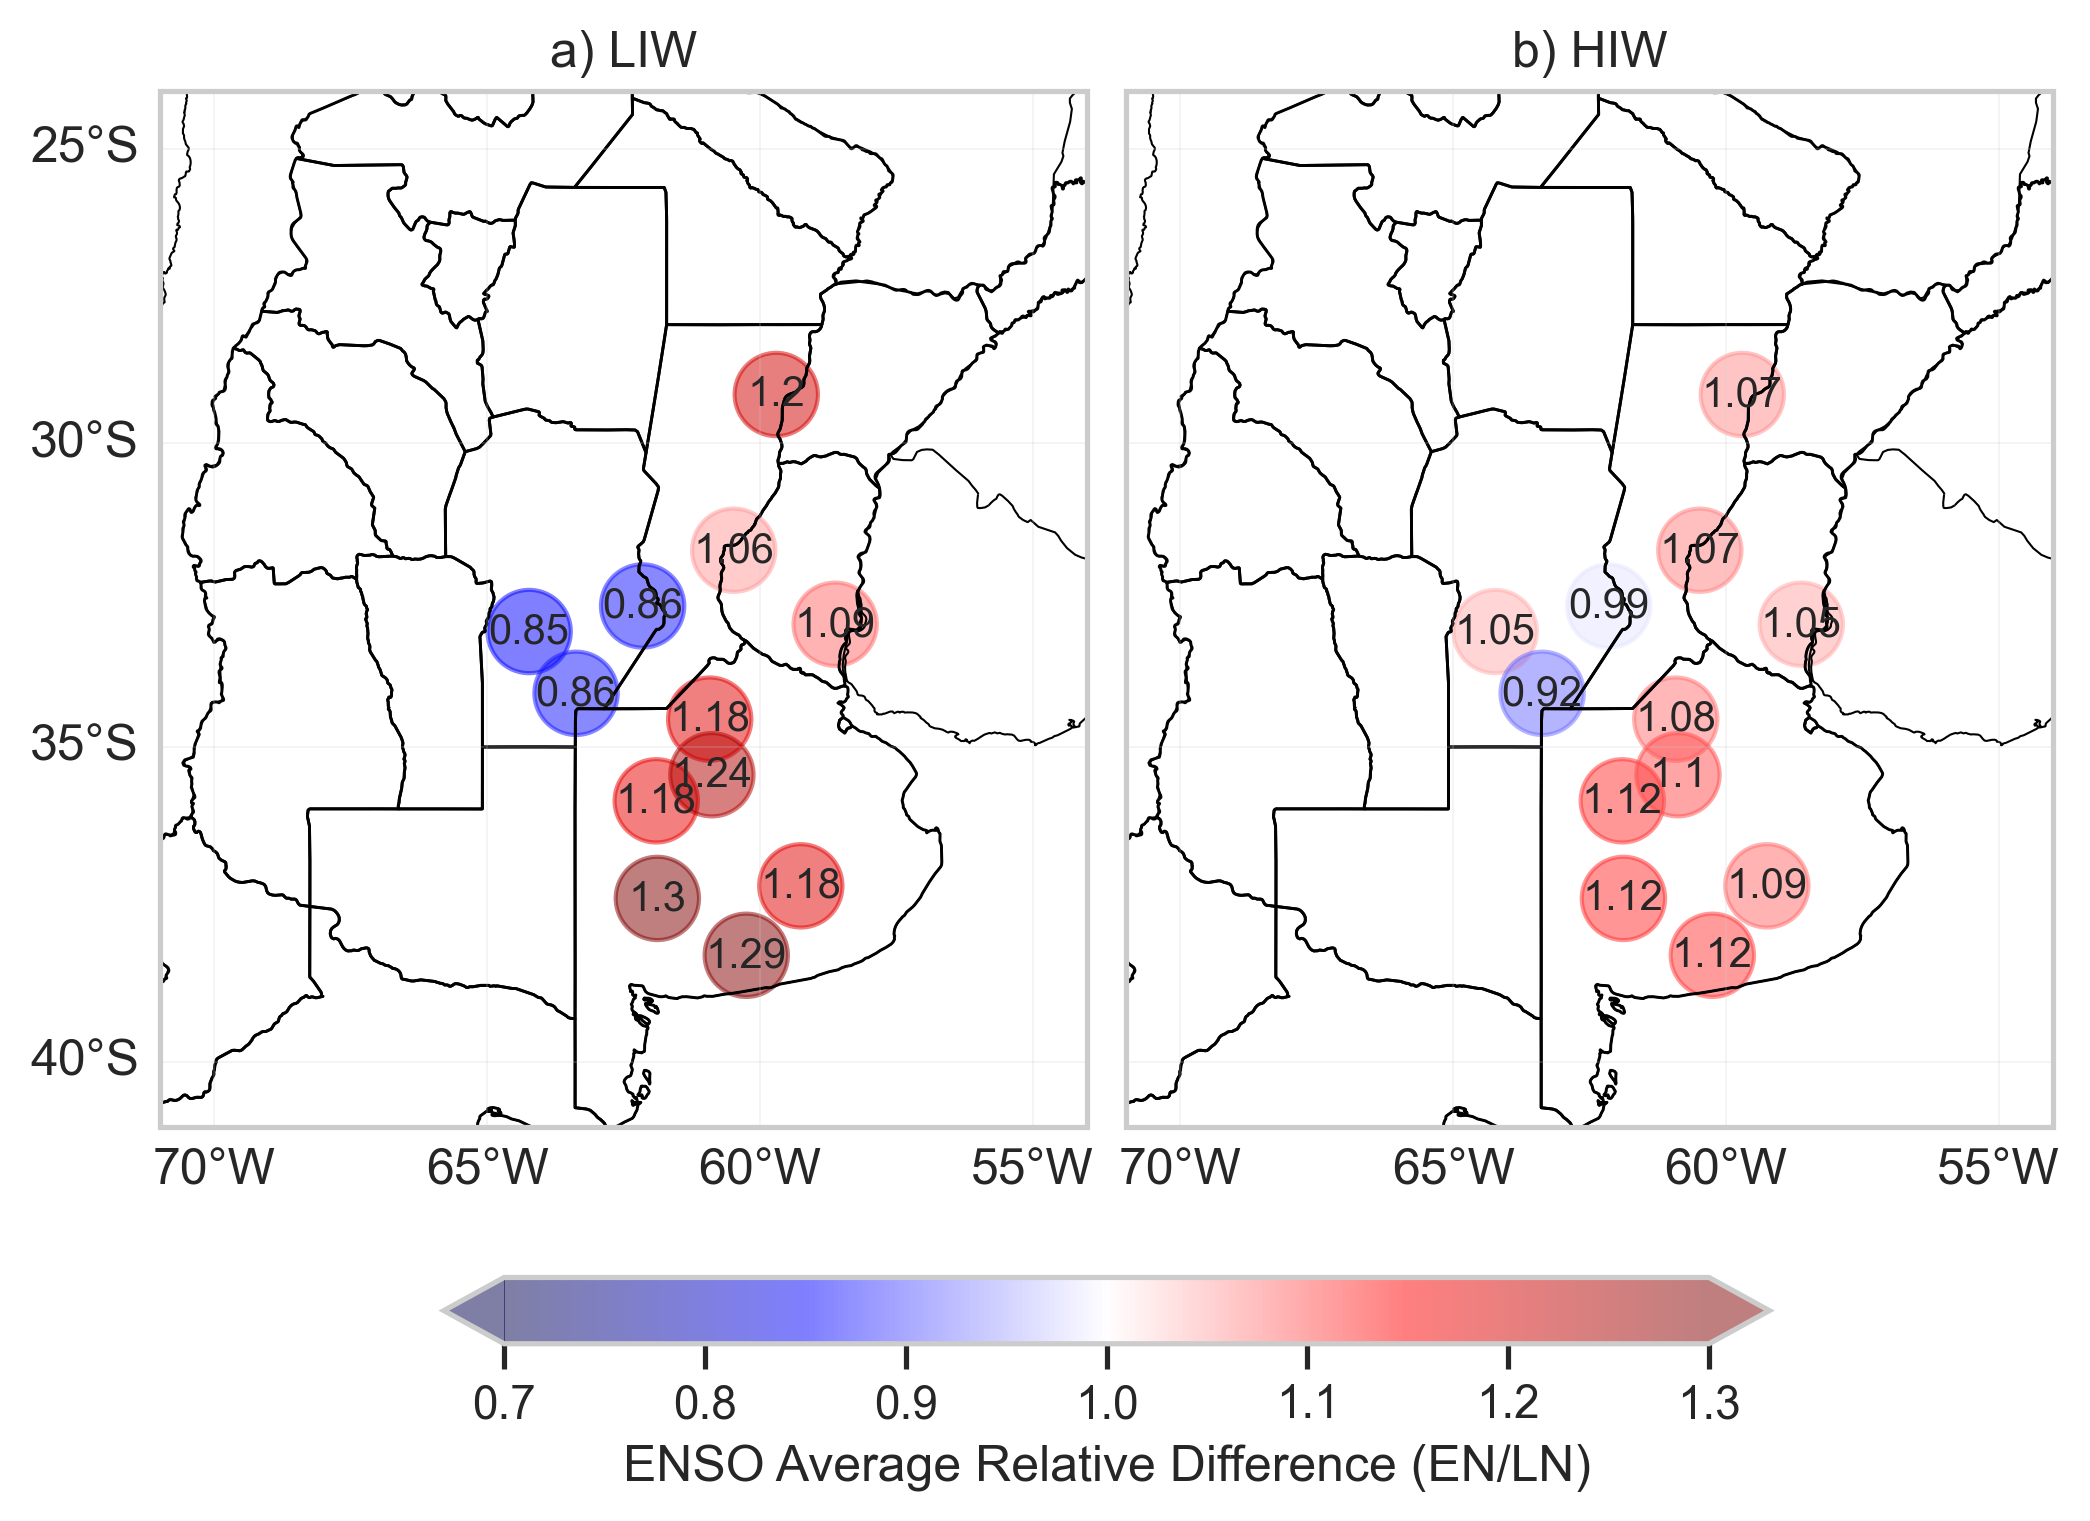

In [15]:
low_difference = df_merge_average_pivot["Low"]["EN"] / df_merge_average_pivot["Low"]["LN"]
high_difference = df_merge_average_pivot["High"]["EN"] /  df_merge_average_pivot["High"]["LN"]

map_plot(longitude = df_merge_average_pivot["longitude"],
    latitude = df_merge_average_pivot["latitude"],
    texts  = [low_difference.round(2),high_difference.round(2)],
    colors = [low_difference,high_difference],
    titles = ["a) LIW","b) HIW"],
    cmap  = "seismic",
    cbar_title = "ENSO Average Relative Difference (EN/LN)",
    vmin=0.7, vmax=1.3,
    extend="both",
    cbar_ticks=None,
    cbar_ticklabels=None,
)

plt.savefig(files_plots + "ENSO_map_yield_average_relative_difference_sw.png",bbox_inches='tight')

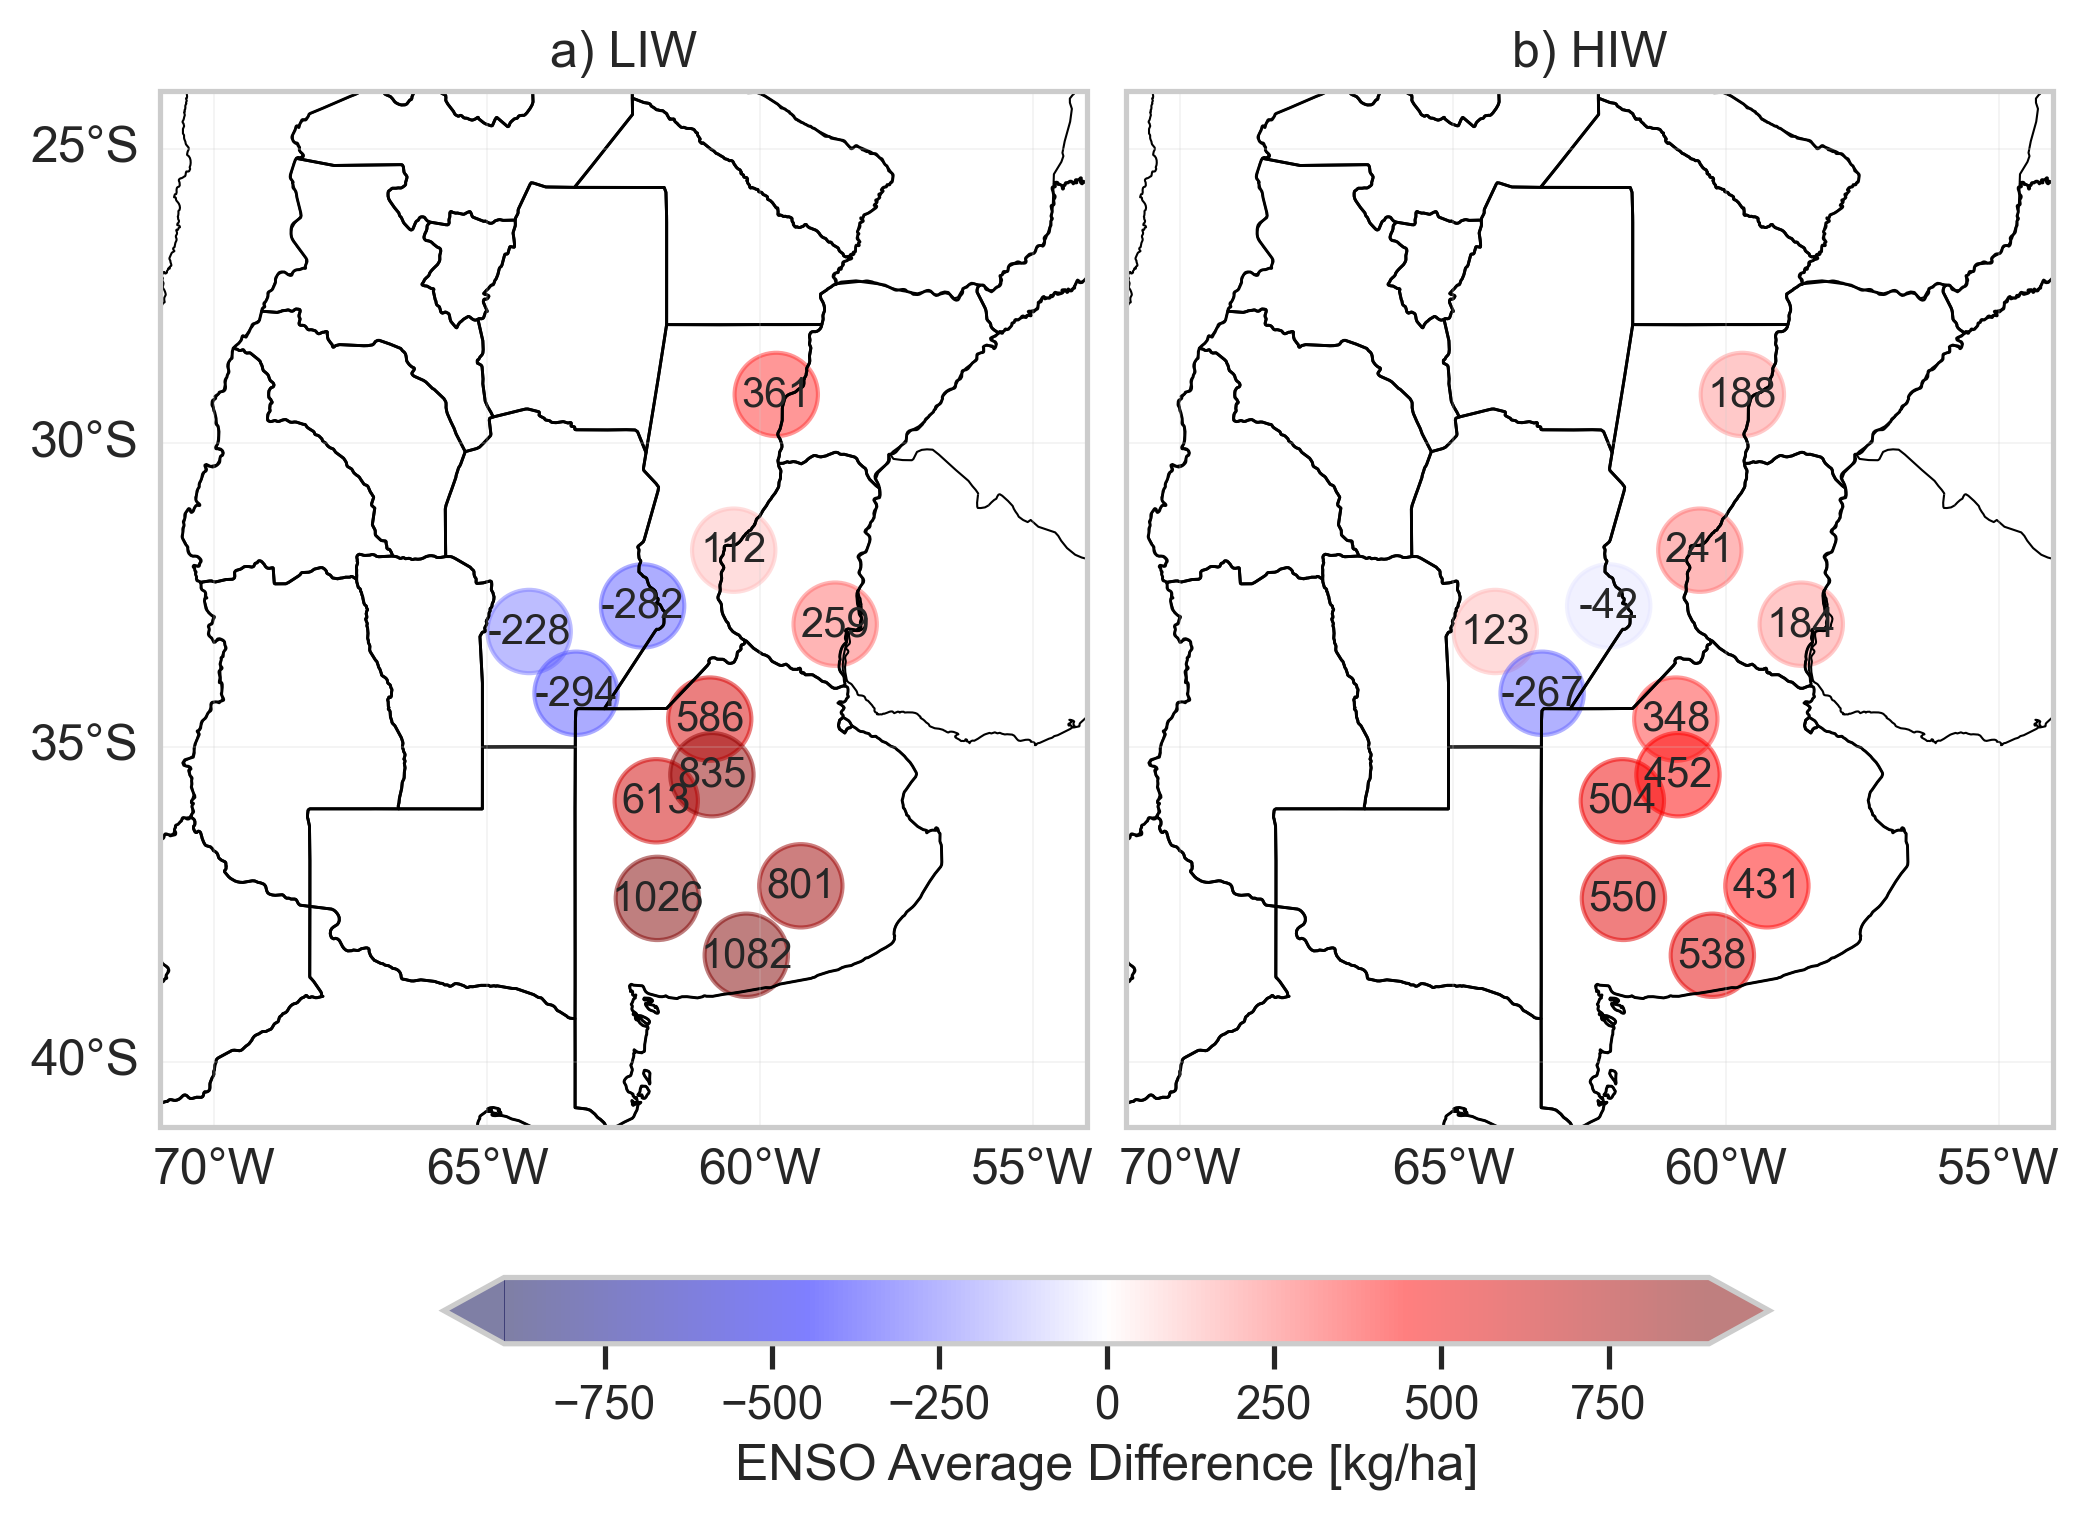

In [16]:
low_difference = df_merge_average_pivot["Low"]["EN"] -  df_merge_average_pivot["Low"]["LN"]
high_difference = df_merge_average_pivot["High"]["EN"] -  df_merge_average_pivot["High"]["LN"]

map_plot(longitude = df_merge_average_pivot["longitude"],
    latitude = df_merge_average_pivot["latitude"],
    texts  = [low_difference.astype(int),high_difference.astype(int)],
    colors = [low_difference,high_difference],
    titles = ["a) LIW","b) HIW"],
    cmap  = "seismic",
    cbar_title = "ENSO Average Difference [kg/ha]",
    vmin=-900, vmax=900,
    extend="both",
    cbar_ticks=None,
    cbar_ticklabels=None,
)

plt.savefig(files_plots + "ENSO_map_yield_average_difference_sw.png",bbox_inches='tight')

# Analysis with precipitation data

In [17]:
df_all = pd.merge(
    df_precip,
    df_merge,
    on = ["location","year"],
    how = "left")

## precipitation patterns

In [18]:
col = "prcp_sum_30_rollmean5"
df_summary = df_all.groupby(["location","julian_day",phase]).apply(
    lambda g: pd.Series(
        {"prcp_sum_30_rollmean5_median":g[col].quantile(0.5),
       "prcp_sum_30_rollmean5_q05":g[col].quantile(0.05),
       "prcp_sum_30_rollmean5_q95":g[col].quantile(0.95)}
    )
).reset_index()

In [19]:
df_summary = df_summary[
    df_summary["phase"] != "N"
].copy()
df_summary[phase] = df_summary[phase].cat.remove_unused_categories()


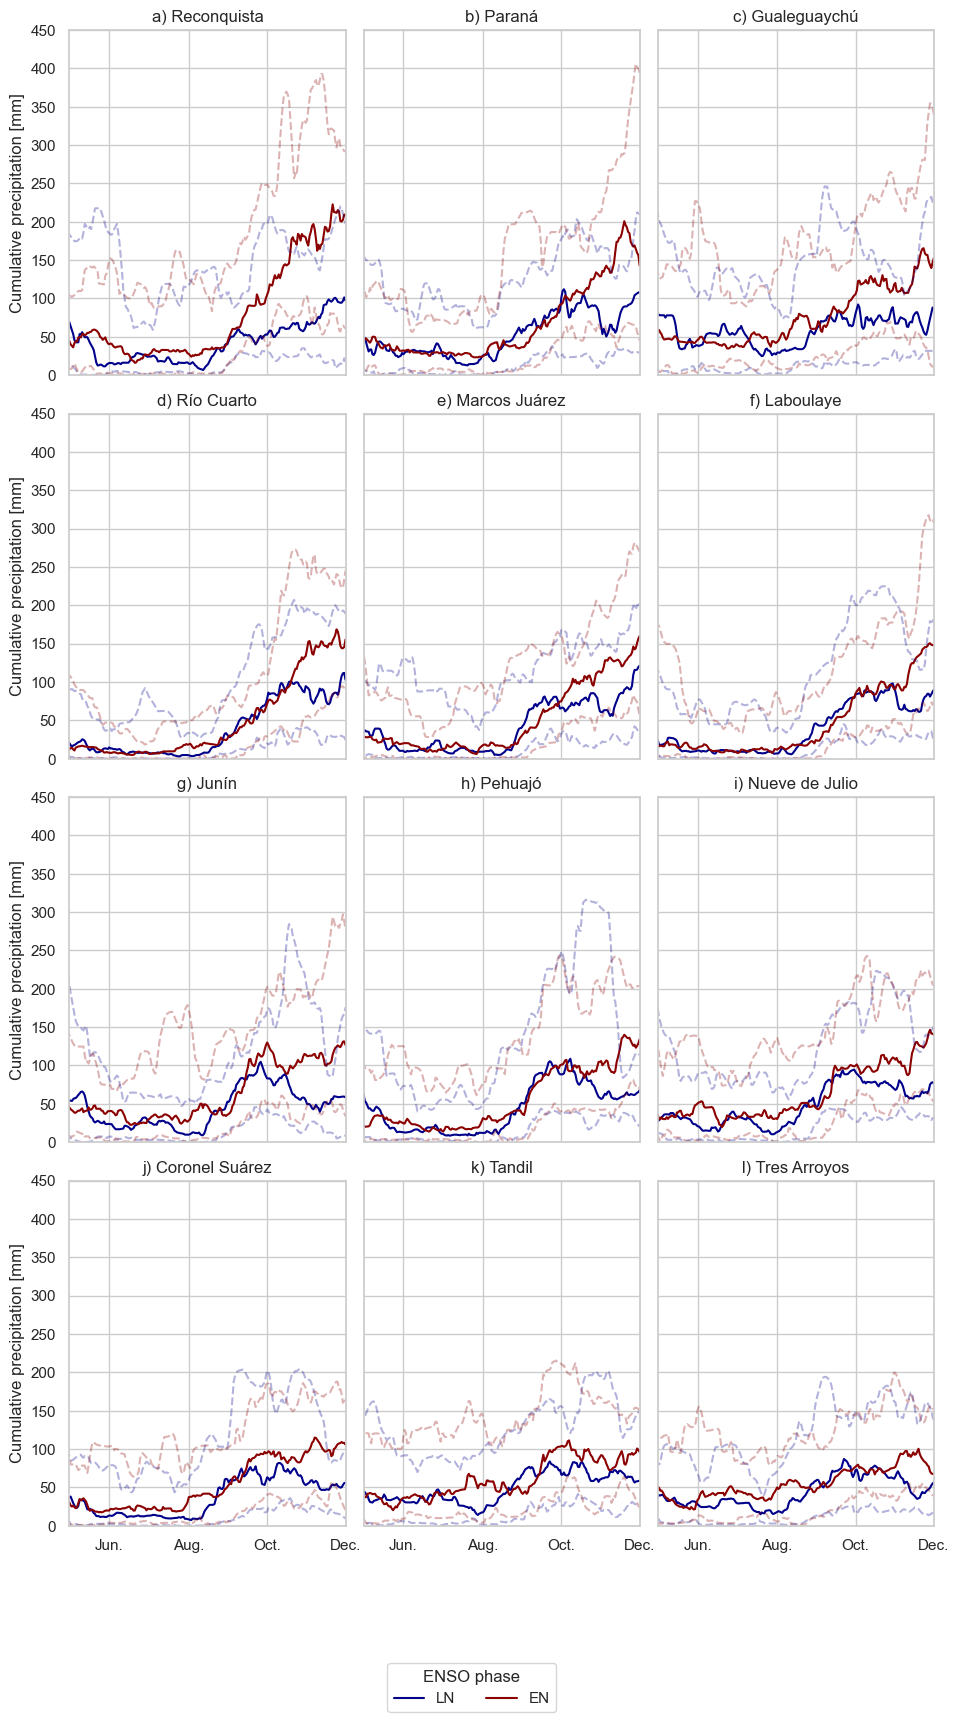

In [21]:
palette = {"LN":"darkblue","EN":"darkred"}
g = facet_plot(
    df_summary,
    sns.lineplot, 
    col="location",
    col_wrap=3,
    height = 4, aspect = 0.8,
    x="julian_day",
    y="prcp_sum_30_rollmean5_median",
    hue=phase,
    palette=palette,
    legend_title="ENSO phase",
    legend=True
)


g.map_dataframe(
    sns.lineplot, 
    "julian_day",y =  "prcp_sum_30_rollmean5_q05" ,  
    linestyle = "dashed",hue=phase,
    palette=palette,
    alpha=0.3,
)
g.map_dataframe(
    sns.lineplot, 
    "julian_day",y =  "prcp_sum_30_rollmean5_q95" ,  
    linestyle = "dashed",hue=phase,
    palette=palette,
    alpha=0.3,
)

g.set(xlabel = "",
      ylabel="Cumulative precipitation [mm]",
    xticks = [59, 120, 181, 243, 304, 365],
    xticklabels = ['Feb.', 'Apr.', 'Jun.','Aug.', 'Oct.', 'Dec.'],
    xlim=(150,365),
     ylim = (0,450))


plt.savefig(files_plots + "ENSO_precipitation.png",bbox_inches='tight')

# Make groups and run montecarlo simulations again

In [22]:
groups={"Reconquista":"North", "Paraná":"North", "Gualeguaychú":"North",
        "Río Cuarto":"West", "Marcos Juárez":"West","Laboulaye":"West",
        "Junín":"Central", "Pehuajó":"Central", "Nueve de Julio": "Central",
        "Coronel Suárez":"South", "Tandil":"South", "Tres Arroyos":"South"    
}
df_all["groups"] = df_all["location"].map(groups)

In [34]:
def montecarlo_sim_group(data = df_all):
    np.random.seed(42)
    df_filtered = data[data["julian_day"] > 120].copy()

    list_simulation = []
    for ph in df_filtered[phase].unique():

        df_phase = df_filtered[df_filtered[phase] == ph]
        years = df_phase["year"].unique()
    
        for i in range(500):
    
            # Sample 60% of the years for this phase
            years_sub = np.random.choice(
                years,
                size=int(len(years) * 0.6),
                replace=False
            )
    
            df_subsample = df_phase[df_phase["year"].isin(years_sub)]
    
            # Correlations
            corr = (
                df_subsample
                .groupby(["groups", "julian_day", "initial_sw"])
                [["prcp_sum_30_rollmean5", "yield_kg_ha"]]
                .corr()
            )
    
            pearson = (
                corr
                .xs("prcp_sum_30_rollmean5", level=-1)["yield_kg_ha"]
                .rename("pearson")
                .reset_index()
            )
    
            pearson["phase"] = ph
            pearson["sim_number"] = i + 1
    
            list_simulation.append(pearson)
    return pd.concat(list_simulation)

In [58]:
if not os.path.isfile(files_dataout + "enso_df_simulations_group.csv"):
    df_simulations_group = montecarlo_sim_group().reset_index()
    df_simulations_group.to_csv(files_dataout + "enso_df_simulations_group.csv",index=False)
    print("file was created again and saved")
else:
    df_simulations_group = pd.read_csv(files_dataout + "enso_df_simulations_group.csv")
    print("file was extracted")

# Remove Neutralö and reorder categories
df_simulations_group = df_simulations_group[df_simulations_group[phase]!="N"].reset_index()
df_simulations_group[phase] = df_simulations_group[phase].astype("category").cat.reorder_categories(["LN","EN"])

file was extracted


In [60]:
indices = df_simulations_group.groupby(["groups","initial_sw",phase,"sim_number"])["pearson"].idxmax().values
df_simulations_idmax_groups = df_simulations_group.iloc[indices,:]

In [62]:

# Sort groups
df_simulations_idmax_groups["groups"] = (
    df_simulations_idmax_groups["groups"]
    .astype("category")
    .cat.reorder_categories(["North", "West", "Central", "South"])
)

### Dual distribution in a single plot
We first create the plots for each group, and then we merge the plots in a single grid

In [63]:
palette = {
    "EN": "darkred",
    "LN": "darkblue"
}

In [64]:
jplots =  {}

panels =  ["a) ", "b) ","c) ","d) "]
groups = ["North","West","Central","South"]

for IW in ["Low","High"]:
    jplots[IW] = {}
    for region , panel in zip( groups ,panels):
            
        dftoplot = df_simulations_idmax_groups[
            (df_simulations_idmax_groups["initial_sw"] == IW) &
            (df_simulations_idmax_groups["groups"] == region) ]
        
        g = sns.jointplot(
            data=dftoplot,
            x="julian_day",
            y="pearson",
            kind="kde",
            fill=False,
            thresh=0.2,
            hue=phase,
            palette = palette,
            legend = False
        )
        
        # Main axis
        g.ax_joint.set(
            
            xlabel = "Critical period",
          xlim = [151,365],
         xticks = [151, 181, 212, 243, 273, 304, 334, 365],
    xticklabels = ["May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
        ylabel = "Pearson correlation",
        yticks = np.arange(0.1,1,0.1),
            ylim = [0.3,1]
        )

        plt.suptitle(panel + region, x=0.2, va="bottom")
        jplots[IW][region] = g
        
        plt.close()

        
        

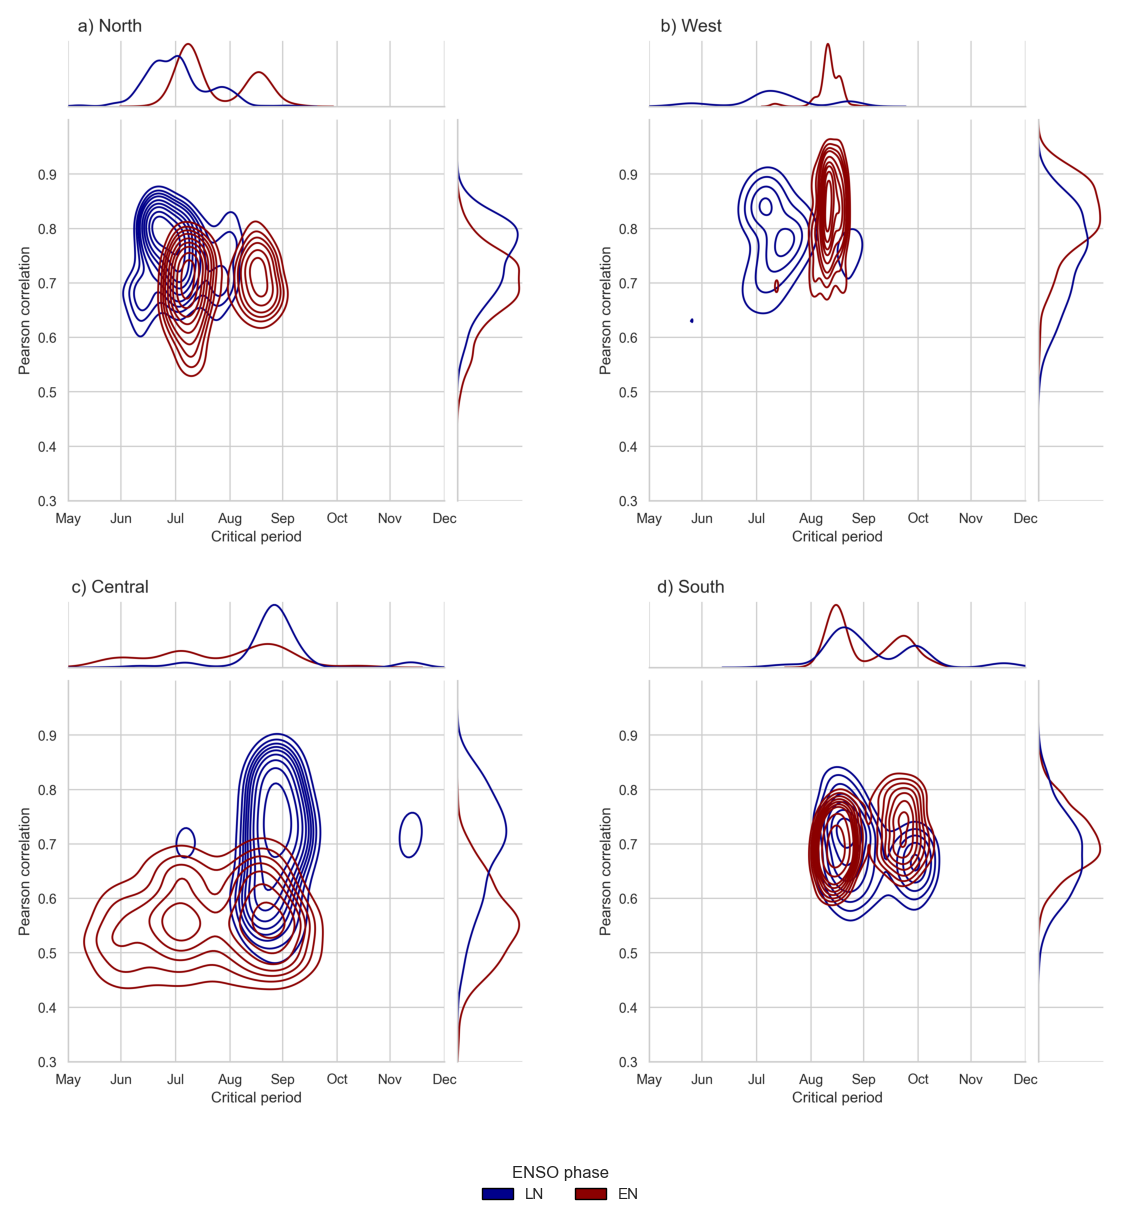

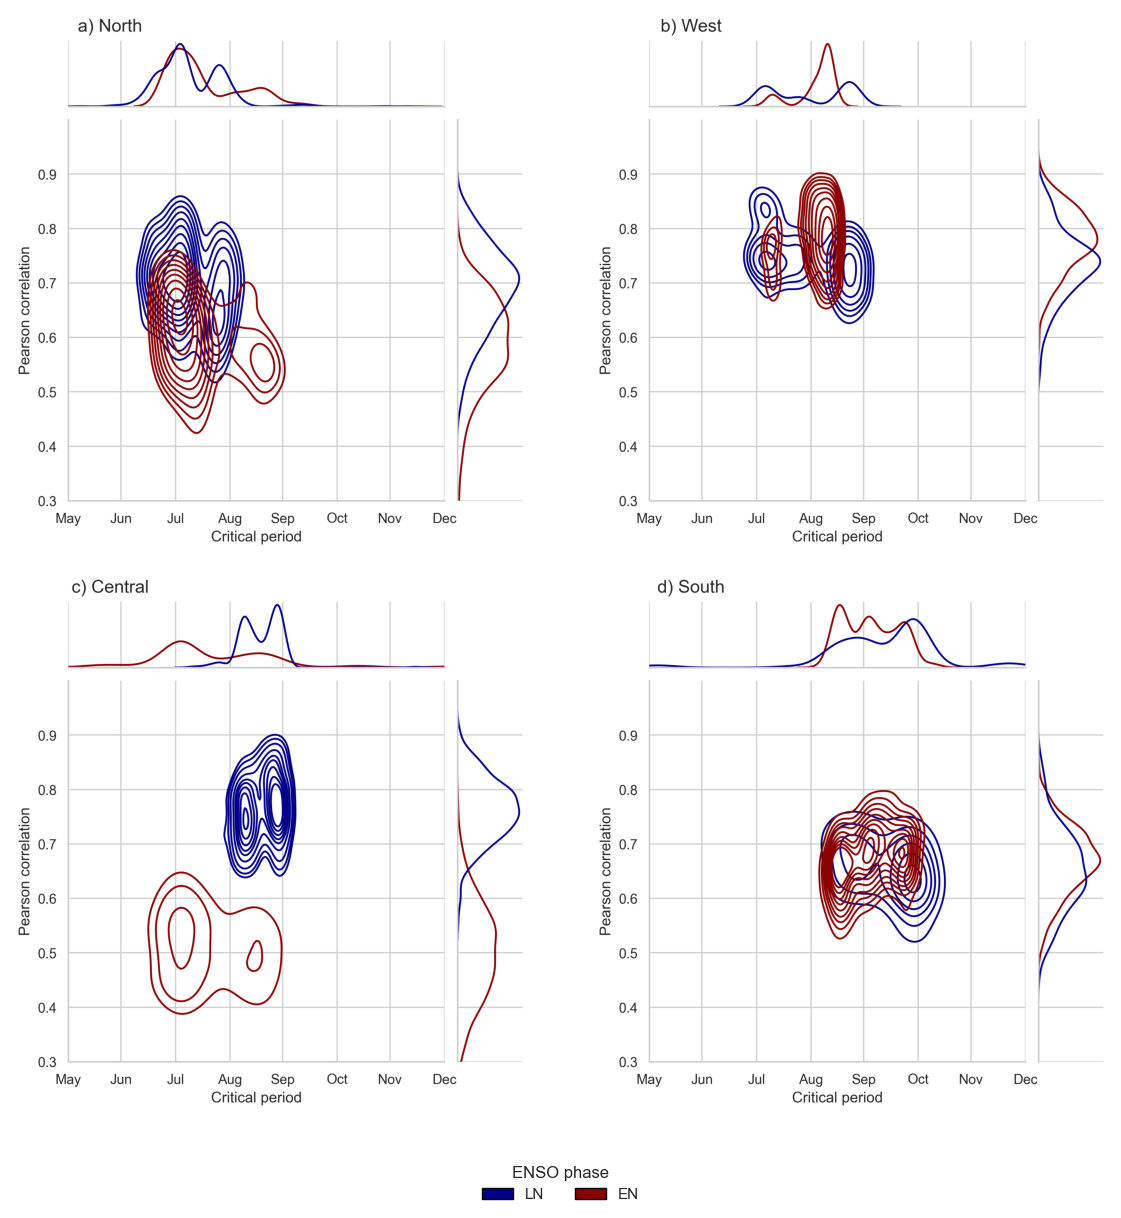

In [65]:

for IW in ["Low","High"]:
    fig, axs = plt.subplots(2, 2, figsize=(12, 12))
    
    for ax, region in zip(axs.flat, groups):
        g = jplots[IW][region]
        g.savefig("temp.png", dpi=300, bbox_inches="tight")
        img = plt.imread("temp.png")
        ax.imshow(img)
        ax.axis("off")
    
    # Create legend handles in desired order
    handles = [
        Patch(facecolor=palette["LN"], edgecolor="black", label="LN"),
        Patch(facecolor=palette["EN"], edgecolor="black", label="EN"),
    ]
    
    fig.legend(
        handles=handles,
        title="ENSO phase",
        loc="lower center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, -0.02),
    )
    
    plt.tight_layout(rect=[0, 0.05, 1, 1])  # Leave space for legend
    
    plt.savefig(files_plots + "ENSO_patchedjoint_distributions_"+ IW + ".png",dpi=600, bbox_inches='tight')